# Final Project: 
## Analysis of Rhode Island’s Redistricting


Population data: based on the decennial census at the Census Block level on 2020 Census Redistricting Data

[2020 Population data](https://redistrictingdatahub.org/dataset/rhode-island-block-pl-94171-2020-by-table/): 2020 Census Block level PL 94-171 (by table) Shapefiles

[2022 State Senate District data](https://redistrictingdatahub.org/dataset/2022-rhode-island-state-senate-districts-approved-plan/): 2022 Adopted RI Senate Plan (SLDU)

[2020 election data](https://redistrictingdatahub.org/dataset/vest-2020-rhode-island-precinct-and-election-results/): 2020 VEST Precinct and Election Results


[2018 election data](https://redistrictingdatahub.org/dataset/vest-2018-rhode-island-precinct-and-election-results/): 2018 Precinct and Election Results (unused)

[2020 County data](https://redistrictingdatahub.org/dataset/rhode-island-county-pl-94171-2020/): 2020 County PL 94-171




Link to our report:
https://www.overleaf.com/project/69cd748c9128b06f913de598

### Gathering and cleaning of data using MAUP

In [1]:
import geopandas as gpd
import maup
from maup import smart_repair
import time
import os

maup.progress.enabled = True

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 2020 Census block-level population data
start_time = time.time()
population_df = gpd.read_file("ShapeFiles/2020 Census Block level PL 94-171 (by table)/ri_pl2020_p2_b.shp")
end_time = time.time()
print("The time to import sc_pl2020_p2_b.shp is:",
      (end_time-start_time)/60, "mins")

print(population_df.columns)


The time to import sc_pl2020_p2_b.shp is: 0.009464069207509359 mins
Index(['GEOID20', 'SUMLEV', 'LOGRECNO', 'GEOID', 'COUNTY', 'P0020001',
       'P0020002', 'P0020003', 'P0020004', 'P0020005', 'P0020006', 'P0020007',
       'P0020008', 'P0020009', 'P0020010', 'P0020011', 'P0020012', 'P0020013',
       'P0020014', 'P0020015', 'P0020016', 'P0020017', 'P0020018', 'P0020019',
       'P0020020', 'P0020021', 'P0020022', 'P0020023', 'P0020024', 'P0020025',
       'P0020026', 'P0020027', 'P0020028', 'P0020029', 'P0020030', 'P0020031',
       'P0020032', 'P0020033', 'P0020034', 'P0020035', 'P0020036', 'P0020037',
       'P0020038', 'P0020039', 'P0020040', 'P0020041', 'P0020042', 'P0020043',
       'P0020044', 'P0020045', 'P0020046', 'P0020047', 'P0020048', 'P0020049',
       'P0020050', 'P0020051', 'P0020052', 'P0020053', 'P0020054', 'P0020055',
       'P0020056', 'P0020057', 'P0020058', 'P0020059', 'P0020060', 'P0020061',
       'P0020062', 'P0020063', 'P0020064', 'P0020065', 'P0020066', 'P00

In [4]:
# 2020 Census block-level voting-age population data
start_time = time.time()
vap_df= gpd.read_file("ShapeFiles/2020 Census Block level PL 94-171 (by table)/ri_pl2020_p4_b.shp")
end_time = time.time()
print("The time to import sc_pl2020_p4_b.shp is:",
      (end_time-start_time)/60, "mins")

print(vap_df.columns)


The time to import sc_pl2020_p4_b.shp is: 0.009285251299540201 mins
Index(['GEOID20', 'SUMLEV', 'LOGRECNO', 'GEOID', 'COUNTY', 'P0040001',
       'P0040002', 'P0040003', 'P0040004', 'P0040005', 'P0040006', 'P0040007',
       'P0040008', 'P0040009', 'P0040010', 'P0040011', 'P0040012', 'P0040013',
       'P0040014', 'P0040015', 'P0040016', 'P0040017', 'P0040018', 'P0040019',
       'P0040020', 'P0040021', 'P0040022', 'P0040023', 'P0040024', 'P0040025',
       'P0040026', 'P0040027', 'P0040028', 'P0040029', 'P0040030', 'P0040031',
       'P0040032', 'P0040033', 'P0040034', 'P0040035', 'P0040036', 'P0040037',
       'P0040038', 'P0040039', 'P0040040', 'P0040041', 'P0040042', 'P0040043',
       'P0040044', 'P0040045', 'P0040046', 'P0040047', 'P0040048', 'P0040049',
       'P0040050', 'P0040051', 'P0040052', 'P0040053', 'P0040054', 'P0040055',
       'P0040056', 'P0040057', 'P0040058', 'P0040059', 'P0040060', 'P0040061',
       'P0040062', 'P0040063', 'P0040064', 'P0040065', 'P0040066', 'P00

In [5]:
# 2020 precinct-level election results (VEST).
# Includes:
#   - 2020 Presidential (G20PREDBID = Biden, G20PRERTRU = Trump)
#   - 2020 U.S. Senate (G20USSDREE = Reed,  G20USSRWAT = Waters)
start_time = time.time()
vest20_df = gpd.read_file("ShapeFiles/2020 Precinct and Election Results/ri_vest_20.shp")
end_time = time.time()
print("The time to import sc_vest_20.shp is:",
      (end_time-start_time)/60, "mins")

print(vest20_df.columns)


The time to import sc_vest_20.shp is: 0.00014262994130452474 mins
Index(['STATEFP20', 'COUNTYFP20', 'VTDST20', 'GEOID20', 'NAME20', 'G20PREDBID',
       'G20PRERTRU', 'G20PRELJOR', 'G20PREOFUE', 'G20PREOLAR', 'G20PREOCAR',
       'G20PREOWRI', 'G20USSDREE', 'G20USSRWAT', 'G20USSOWRI', 'geometry'],
      dtype='object')


In [6]:
# 2020 RI county boundaries
start_time = time.time()
county_df = gpd.read_file("ShapeFiles/ri_pl2020_cnty/ri_pl2020_cnty.shp")
end_time = time.time()
print("The time to import sc_pl2020_cnty.shp is:",
      (end_time-start_time)/60, "mins")
print(county_df.columns)


The time to import sc_pl2020_cnty.shp is: 9.323755900065104e-05 mins
Index(['STATEFP20', 'COUNTYFP20', 'COUNTYNS20', 'GEOID20', 'NAME20',
       'NAMELSAD20', 'LSAD20', 'CLASSFP20', 'MTFCC20', 'CSAFP20',
       ...
       'P0050002', 'P0050003', 'P0050004', 'P0050005', 'P0050006', 'P0050007',
       'P0050008', 'P0050009', 'P0050010', 'geometry'],
      dtype='object', length=348)


In [7]:
# 2022 enacted RI State Senate district boundaries.
start_time = time.time()
sen_df = gpd.read_file("FinalShapeFiles/RI_Senate_D_SubA.shp")
end_time = time.time()
print("The time to import state senate districts is:",
      (end_time-start_time)/60, "mins")

print(sen_df.columns)


The time to import state senate districts is: 3.5766760508219404e-05 mins
Index(['ID', 'DISTRICT', 'DISTRICTN', 'geometry'], dtype='object')


In [8]:
sen_df.shape

(38, 4)

In [9]:
# Only keep necessary population data
population_columns_keep = ['GEOID20','P0020001','P0020002','P0020005',
                           'P0020006','P0020007','P0020008','P0020009',
                           'P0020010','P0020011','geometry']

final_population_df = population_df[population_columns_keep]
final_population_df = final_population_df.rename(columns = {
    'P0020001': 'TOTPOP', 
    'P0020002': 'HISP', 
    'P0020005': 'NH_WHITE', 
    'P0020006': 'NH_BLACK', 
    'P0020007': 'NH_AMIN',
    'P0020008': 'NH_ASIAN', 
    'P0020009': 'NH_NHPI', 
    'P0020010': 'NH_OTHER', 
    'P0020011': 'NH_2MORE'
})

final_population_df.head()


,GEOID20,TOTPOP,HISP,NH_WHITE,NH_BLACK,NH_AMIN,NH_ASIAN,NH_NHPI,NH_OTHER,NH_2MORE,geometry
0,440090515033040,0,0,0,0,0,0,0,0,0,"POLYGON ((-71.47043 41.39267, -71.47016 41.393..."
1,440090513041051,28,1,25,0,0,0,0,0,2,"POLYGON ((-71.60229 41.41279, -71.60224 41.412..."
2,440090508013008,80,0,73,3,0,0,0,0,4,"POLYGON ((-71.82932 41.36955, -71.82932 41.369..."
3,440090509013011,129,2,123,2,0,0,0,0,2,"POLYGON ((-71.80917 41.39745, -71.80911 41.397..."
4,440090515043006,23,0,23,0,0,0,0,0,0,"POLYGON ((-71.49791 41.38452, -71.49788 41.384..."


In [10]:
# Only keep necessary VAP(vote adult population) data
vap_columns_keep = ['GEOID20','P0040001','P0040002','P0040005',
                    'P0040006','P0040007','P0040008','P0040009',
                    'P0040010','P0040011','geometry']

final_vap_df = vap_df[vap_columns_keep]
final_vap_df = final_vap_df.rename(columns = {
    'P0040001': 'VAP',
    'P0040002': 'HVAP', 
    'P0040005': 'WVAP', 
    'P0040006': 'BVAP', 
    'P0040007': 'AMINVAP',
    'P0040008': 'ASIANVAP', 
    'P0040009': 'NHPIVAP', 
    'P0040010': 'OTHERVAP', 
    'P0040011': '2MOREVAP'
})
final_vap_df.head()


,GEOID20,VAP,HVAP,WVAP,BVAP,AMINVAP,ASIANVAP,NHPIVAP,OTHERVAP,2MOREVAP,geometry
0,440090515033040,0,0,0,0,0,0,0,0,0,"POLYGON ((-71.47043 41.39267, -71.47016 41.393..."
1,440090513041051,26,1,23,0,0,0,0,0,2,"POLYGON ((-71.60229 41.41279, -71.60224 41.412..."
2,440090508013008,53,0,47,3,0,0,0,0,3,"POLYGON ((-71.82932 41.36955, -71.82932 41.369..."
3,440090509013011,108,1,103,2,0,0,0,0,2,"POLYGON ((-71.80917 41.39745, -71.80911 41.397..."
4,440090515043006,21,0,21,0,0,0,0,0,0,"POLYGON ((-71.49791 41.38452, -71.49788 41.384..."


In [11]:
# Only keep necessary county data
county_columns_keep = ['COUNTYFP20','NAME20','geometry']

final_county_df = county_df[county_columns_keep]
final_county_df.head()


,COUNTYFP20,NAME20,geometry
0,007,Providence,"POLYGON ((-71.79468 41.85441, -71.79491 41.858..."
1,001,Bristol,"POLYGON ((-71.32898 41.67994, -71.33097 41.686..."
2,005,Newport,"POLYGON ((-71.4219 41.449, -71.41727 41.45595,..."
3,003,Kent,"POLYGON ((-71.48391 41.7316, -71.48362 41.7316..."
4,009,Washington,"MULTIPOLYGON (((-71.52243 41.60257, -71.52208 ..."


In [12]:
# Only keep necessary districting data
senate_columns_keep = ['DISTRICT', 'DISTRICTN', 'geometry']
final_senate_df = sen_df[senate_columns_keep]
final_senate_df.head()


,DISTRICT,DISTRICTN,geometry
0,1,1,"POLYGON ((-71.41883 41.82604, -71.41873 41.826..."
1,2,2,"POLYGON ((-71.42061 41.78618, -71.42148 41.786..."
2,3,3,"POLYGON ((-71.3978 41.8099, -71.39804 41.81028..."
3,4,4,"POLYGON ((-71.47283 41.83753, -71.47286 41.837..."
4,5,5,"POLYGON ((-71.43568 41.81177, -71.43606 41.811..."


In [13]:
# Rename the election columns for easier classification
election_df = vest20_df.rename(columns = {
    'G20PREDBID': 'PRES20D',  
    'G20PRERTRU': 'PRES20R',  
    'G20USSDREE': 'SEN20D',   
    'G20USSRWAT': 'SEN20R'
})

election_columns_keep = [
    'COUNTYFP20',
    'GEOID20', # Unique ID
    'NAME20',
    'PRES20D', 'PRES20R', 
    'SEN20D', 'SEN20R',
    'geometry' 
]

final_election_df = election_df[election_columns_keep]
final_election_df.head()

,COUNTYFP20,GEOID20,NAME20,PRES20D,PRES20R,SEN20D,SEN20R,geometry
0,009,44009443208,South Kingstown 8,1562,839,1615,762,"POLYGON ((-71.60673 41.41403, -71.60623 41.415..."
1,007,44007440724,Cranston 24,1322,290,1310,271,"POLYGON ((-71.40395 41.77325, -71.40316 41.774..."
2,005,44005ZZZZZZ,Voting Districts Not Defined,0,0,0,0,"POLYGON ((-71.50944 41.30773, -71.5066 41.3126..."
3,005,44005441501,JAMESTOWN 1,1547,651,1621,564,"POLYGON ((-71.38543 41.55424, -71.38534 41.554..."
4,005,44005441502,JAMESTOWN 2,1261,562,1344,464,"POLYGON ((-71.4219 41.449, -71.41727 41.45595,..."


### Clean the data by using maup.doctor()

In [14]:
# Put everything into utm crs. (smart_repair needs this, and it's best to have everything at the same crs.)

final_population_df = final_population_df.to_crs(final_population_df.estimate_utm_crs())
final_vap_df = final_vap_df.to_crs(final_vap_df.estimate_utm_crs())
final_county_df = final_county_df.to_crs(final_county_df.estimate_utm_crs())
final_senate_df = final_senate_df.to_crs(final_senate_df.estimate_utm_crs())
final_election_df = final_election_df.to_crs(final_election_df.estimate_utm_crs())

In [15]:
maup.doctor(final_population_df)

100%|██████████| 25649/25649 [00:07<00:00, 3322.94it/s]


True

In [16]:
maup.doctor(final_vap_df)

100%|██████████| 25649/25649 [00:07<00:00, 3451.29it/s]


True

In [17]:
maup.doctor(final_county_df)

100%|██████████| 5/5 [00:00<00:00, 896.87it/s]


True

In [18]:
maup.doctor(final_senate_df)

100%|██████████| 38/38 [00:00<00:00, 724.39it/s]


There are 73 overlaps.
There are 1280 holes.


False

In [19]:
maup.doctor(final_election_df)

100%|██████████| 423/423 [00:00<00:00, 1577.29it/s]


True

We need to do smart repair with our 2012 to 2021 RI Senate Districts data.

In [20]:
final_senate_df = smart_repair(final_senate_df) 

Snapping all geometries to a grid with precision 10^( -4 ) to avoid GEOS errors.
Identifying overlaps...


100%|██████████| 1513/1513 [00:00<00:00, 17824.74it/s]

Resolving overlaps...
Assigning order 2 pieces...


Filling gaps...


Gaps to fill: 100%|██████████| 6/6 [00:00<00:00, 42.99it/s]


In [21]:
maup.doctor(final_senate_df)

100%|██████████| 38/38 [00:00<00:00, 721.71it/s]


True

In [22]:
final_senate_df.shape

(38, 3)

In [23]:
# confirm the senate-map holes don't cause any population loss
# when we assign blocks to districts.
original_total_pop = final_population_df["TOTPOP"].sum()

assignment = maup.assign(final_population_df, final_senate_df)
captured_total = final_population_df["TOTPOP"].groupby(assignment).sum().sum()

print(f"Total population in original block: {original_total_pop}")
print(f"Population after assign: {captured_total}")
print(f"Loss population: {original_total_pop - captured_total}")

100%|██████████| 38/38 [00:00<00:00, 86.06it/s] 

Total population in original block: 1097379
Population after assign: 1097379
Loss population: 0


As we don't lose population here, the hole in senate map is acceptable.

### Nest precincts within counties

In [24]:
# Repair the election precincts so they nest cleanly within county boundaries.
final_df = smart_repair(final_election_df, nest_within_regions = final_county_df)


100%|██████████| 5/5 [00:00<00:00, 883.98it/s]


Snapping all geometries to a grid with precision 10^( -4 ) to avoid GEOS errors.


100%|██████████| 5/5 [00:00<00:00, 340.11it/s]


Identifying overlaps...


100%|██████████| 432/432 [00:00<00:00, 4875.34it/s]


Resolving overlaps and filling gaps...


100%|██████████| 5/5 [00:00<00:00, 335.96it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]
Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]


### Change small boundaries to queen adjacencies

In [25]:
# Inspect the shortest shared borders between adjacent precincts.
# Very short borders (a few meters) are usually slivers from the geometry and
# we'll convert them into queen adjacencies in the next step.
import copy
boundaries = copy.deepcopy(final_df)
boundaries["geometry"] = boundaries.geometry.boundary  # extract precinct boundaries
neighbors = gpd.sjoin(boundaries, final_df, predicate="intersects")
neighbors = neighbors[neighbors.index != neighbors.index_right] # drop self-matches

# Length of each shared border between two precincts.
borders = list(neighbors.apply(
    lambda row: row.geometry.intersection(boundaries.loc[row.index_right, "geometry"]).length, axis=1
))

borders.sort()
print(borders[:500])



[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

In [26]:
# Make sure all small boundaries to queen adjacencies
final_df = smart_repair(final_df, min_rook_length = 30)

boundaries = copy.deepcopy(final_df)
boundaries["geometry"] = boundaries.geometry.boundary
neighbors = gpd.sjoin(boundaries, final_df, predicate="intersects")
neighbors = neighbors[neighbors.index != neighbors.index_right]

# compute shared border length using intersection
borders = list(neighbors.apply(
    lambda row: row.geometry.intersection(boundaries.loc[row.index_right, "geometry"]).length, axis=1
))

borders.sort()
print(borders[:500])

Snapping all geometries to a grid with precision 10^( -4 ) to avoid GEOS errors.
Identifying overlaps...


100%|██████████| 432/432 [00:00<00:00, 8676.83it/s]


Resolving overlaps...
Filling gaps...


Gaps to simplify: 0it [00:00, ?it/s]
Gaps to fill: 0it [00:00, ?it/s]


Converting small rook adjacencies to queen...


100%|██████████| 4/4 [00:00<00:00, 2680.92it/s]


[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,

In [27]:
maup.doctor(final_df)

100%|██████████| 423/423 [00:00<00:00, 1618.36it/s]


True

### Assign blocks to precints for populations

In [28]:

blocks_to_precincts_assignment = maup.assign(final_population_df.geometry, final_df.geometry)
vap_blocks_to_precincts_assignment = maup.assign(final_vap_df.geometry, final_df.geometry)

100%|██████████| 423/423 [00:01<00:00, 335.32it/s]


In [29]:
blocks_to_precincts_assignment

0         89
1        109
2        116
3        113
4         89
        ... 
25644     19
25645     31
25646     31
25647     14
25648     29
Length: 25649, dtype: int64

In [30]:
for name in final_population_df.columns:
    if name != 'geometry':
        final_df[name] = final_population_df[name].groupby(blocks_to_precincts_assignment).sum()
for name in final_vap_df.columns:
    if name != 'geometry':
        final_df[name] = final_vap_df[name].groupby(vap_blocks_to_precincts_assignment).sum()

### Add Senate District Data

In [31]:
# Add Senate District Data
precincts_to_districts_assignment = maup.assign(final_df.geometry, final_senate_df.geometry) 
final_df["SEND"] = precincts_to_districts_assignment

100%|██████████| 38/38 [00:00<00:00, 260.32it/s]


In [32]:
final_df.columns

Index(['COUNTYFP20', 'GEOID20', 'NAME20', 'PRES20D', 'PRES20R', 'SEN20D',
       'SEN20R', 'geometry', 'TOTPOP', 'HISP', 'NH_WHITE', 'NH_BLACK',
       'NH_AMIN', 'NH_ASIAN', 'NH_NHPI', 'NH_OTHER', 'NH_2MORE', 'VAP', 'HVAP',
       'WVAP', 'BVAP', 'AMINVAP', 'ASIANVAP', 'NHPIVAP', 'OTHERVAP',
       '2MOREVAP', 'SEND'],
      dtype='object')

In [33]:
final_df.head()

,COUNTYFP20,GEOID20,NAME20,PRES20D,PRES20R,SEN20D,SEN20R,geometry,TOTPOP,HISP,...,VAP,HVAP,WVAP,BVAP,AMINVAP,ASIANVAP,NHPIVAP,OTHERVAP,2MOREVAP,SEND
0,009,4400905130220124400905130220034400905130410304...,South Kingstown 8,1562,839,1615,762,"POLYGON ((282137.751 4587999.408, 282184.655 4...",3317,77,...,2854,56,2659,10,3,28,0,10,88,36
1,007,4400701340010044400701340010064400701340030134...,Cranston 24,1322,290,1310,271,"POLYGON ((300198.31 4627393.802, 300267.466 46...",2490,198,...,2066,130,1757,55,4,45,1,7,67,27
2,005,4400504080030004400504040030524400504070020354...,Voting Districts Not Defined,0,0,0,0,"POLYGON ((289927.971 4575956.908, 290181.441 4...",0,0,...,0,0,0,0,0,0,0,0,0,11
3,005,4400504130030154400504130030274400504130030184...,JAMESTOWN 1,1547,651,1621,564,"POLYGON ((301064.263 4603033.208, 301072.86 46...",2736,64,...,2281,41,2144,14,6,12,0,8,56,12
4,005,4400504130050624400504130010554400504130050504...,JAMESTOWN 2,1261,562,1344,464,"POLYGON ((297819.131 4591324.141, 297695.539 4...",2823,62,...,2407,42,2276,19,1,23,0,10,36,12


<Axes: >

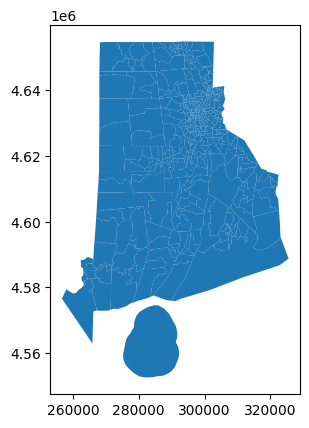

In [34]:
final_df.plot()

In [35]:
# store
directory = "./FinalShapeFiles"
if not os.path.exists(directory):
    os.makedirs(directory)
final_df.to_file("./FinalShapeFiles/RI.shp")